In [1]:
import pandas as pd

data = pd.read_csv("../data/processed/model_features.csv")
data['first_order_date'] = pd.to_datetime(data['first_order_date'])

print(data.shape)
data.head()

(96096, 13)


,customer_unique_id,first_order_date,last_order_date,n_orders,customer_lifetime_days,total_spend,avg_order_value,n_items,n_distinct_categories,avg_review_score,clv_target,is_repeat_customer,delivery_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,0,141.90,141.90,1.0,1.0,5.0,141.90,0,6.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,0,27.19,27.19,1.0,1.0,4.0,27.19,0,3.0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,0,86.22,86.22,1.0,1.0,3.0,86.22,0,25.0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,0,43.62,43.62,1.0,1.0,4.0,43.62,0,20.0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,0,196.89,196.89,1.0,1.0,5.0,196.89,0,13.0


In [2]:
data = data.sort_values('first_order_date')
cutoff = data['first_order_date'].quantile(0.8)
train = data[data['first_order_date'] <= cutoff]
test = data[data['first_order_date'] > cutoff]
print(train.shape, test.shape)

(76877, 13) (19219, 13)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
feature_cols = ['avg_order_value', 'n_items', 'n_distinct_categories',
'delivery_days', 'avg_review_score']
X_train, y_train = train[feature_cols].fillna(0), train['is_repeat_customer']
X_test, y_test = test[feature_cols].fillna(0), test['is_repeat_customer']
baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)
print("Baseline AUC:", roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1]))
xgb_clf = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
xgb_clf.fit(X_train, y_train)
print("XGB AUC:", roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]))

Baseline AUC: 0.8347988634366343
XGB AUC: 0.9265823762727787


Stage 2 — CLV regressor (on repeat customers, or full population — try both and compare)

In [4]:
from sklearn.metrics import mean_absolute_error
reg_train = train.dropna(subset=['clv_target'])
reg_test = test.dropna(subset=['clv_target'])
X_train_r, y_train_r = reg_train[feature_cols].fillna(0), reg_train['clv_target']
X_test_r, y_test_r = reg_test[feature_cols].fillna(0), reg_test['clv_target']
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05)
xgb_reg.fit(X_train_r, y_train_r)
preds = xgb_reg.predict(X_test_r)
print("MAE:", mean_absolute_error(y_test_r, preds))

MAE: 10.115066945534767


In [5]:
import mlflow

mlflow.set_experiment("olist-clv")

with mlflow.start_run(run_name="xgb_clv_vl"):
    mlflow.log_params({"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05})
    mlflow.log_metric("mae", mean_absolute_error(y_test_r, preds))
    mlflow.xgboost.log_model(xgb_reg, "model")


d:\Desktop\E-Commerce CLV + Churn Risk Prediction\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/07/18 21:22:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


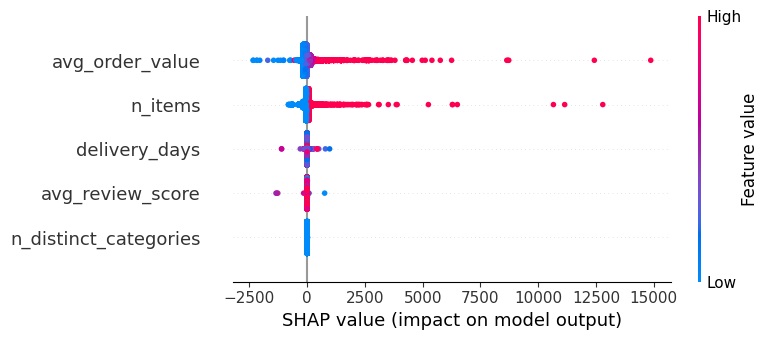

In [6]:
import shap
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test_r)
shap.summary_plot(shap_values, X_test_r)

In [7]:
import shap, xgboost
print("shap:", shap.__version__)
print("xgboost:", xgboost.__version__)

shap: 0.49.1
xgboost: 2.1.4


In [8]:
import joblib
joblib.dump(xgb_clf, "../src/churn_model.pkl")
joblib.dump(xgb_reg, "../src/clv_model.pkl")

['../src/clv_model.pkl']